# Defination

#### 1. What are LLMs?

LLM (Large Language Model) is a type of artificial intelligence model designed to understand, process, and generate human language. LLMs are trained on very large amounts of text data and learn patterns in language, allowing them to perform tasks such as answering questions, summarizing text, translating languages, generating code, and writing content.

Examples of LLMs include GPT, Llama, Claude, and Gemini.

#### 2. How large is an LLM?

The "large" in Large Language Model mainly refers to the number of parameters in the model and the large amount of data and computing resources used during training.

A parameter is a value learned by the model during training. Generally, more parameters allow a model to learn more complex patterns, although a larger model does not automatically mean it will perform better in every situation.

LLMs can range from millions to hundreds of billions or even trillions of parameters.

For example:

Small models → millions of parameters
Medium models → billions of parameters
Large models → tens or hundreds of billions of parameters
Very large models → potentially trillions of parameters

#### 3. General-Purpose Models

A general-purpose model is an AI model trained to perform a wide range of tasks rather than being designed for only one specific task.

For example, a general-purpose LLM can be used for:

Question answering,
Text generation,
Summarization,
Translation,
Classification,
Coding,
Information extraction.

Models such as GPT and Llama are examples of general-purpose language models.

#### 4. Pre-training and Fine-tuning
Pre-training

Pre-training is the initial training stage where an LLM learns general language patterns from a very large dataset containing text from many different sources.

During pre-training, the model learns things such as:

Grammar
Vocabulary
Sentence structure
Relationships between words
General patterns in language
Some knowledge contained in the training data

Pre-training requires a large amount of data, computational power, and time.

Fine-tuning

Fine-tuning is the process of taking a pre-trained model and training it further on a smaller, task-specific dataset.

For example, a general-purpose model can be fine-tuned for:

Sentiment analysis
Medical text classification
Customer support
Legal document analysis
Spam detection

Simple idea:

Pre-trained model → Task-specific data → Fine-tuned model

#### 5. What can LLMs be used for?

LLMs can be used for many natural language and programming tasks, including:

Text generation – writing articles, emails, stories, and reports.
Question answering – answering questions based on learned or provided information.
Summarization – converting long documents into shorter summaries.
Translation – translating text between different languages.
Text classification – classifying text such as spam/not spam or positive/negative sentiment.
Information extraction – extracting names, dates, locations, and other information from text.
Code generation – generating, explaining, debugging, and modifying programming code.
Chatbots and virtual assistants – interacting with users using natural language.
Content creation – helping create blogs, descriptions, scripts, and other content.
Reasoning and problem solving – assisting with mathematical, logical, and analytical tasks.

| Topic                     | Meaning                                                            |
| ------------------------- | ------------------------------------------------------------------ |
| **LLM**                   | AI model designed to understand and generate human language        |
| **Parameters**            | Values learned by the model during training                        |
| **General-purpose model** | Model capable of performing many different tasks                   |
| **Pre-training**          | Initial training on a large amount of general data                 |
| **Fine-tuning**           | Further training for a specific task                               |
| **LLM applications**      | Chatbots, summarization, translation, coding, classification, etc. |


---

## Transformer Architecture

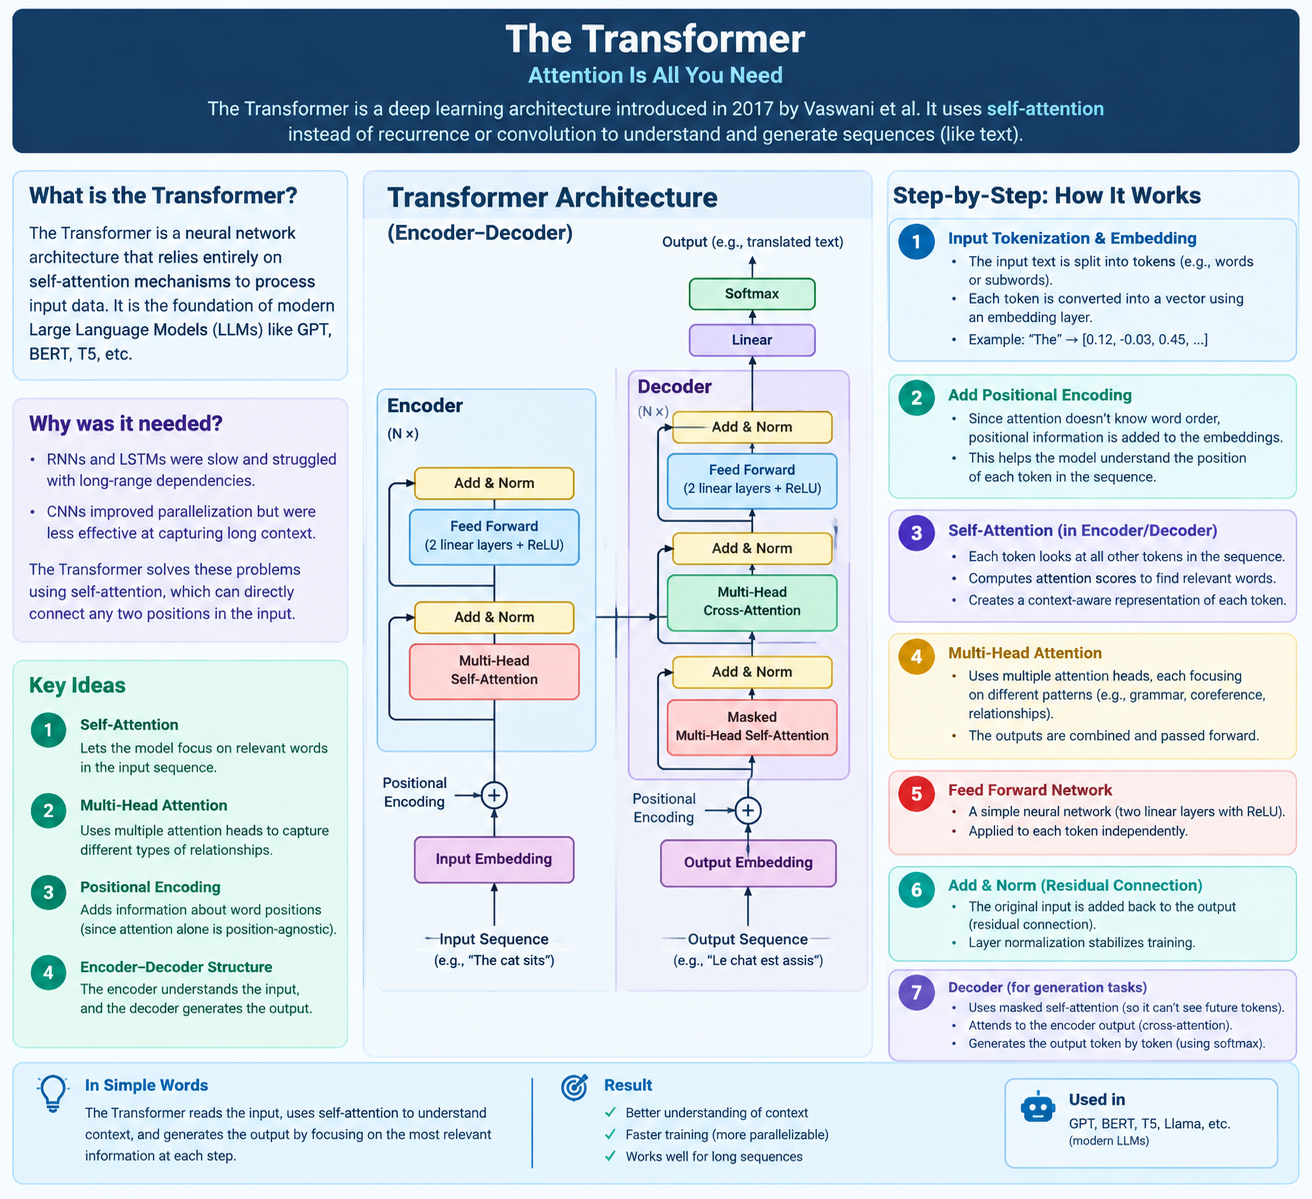

### Defination and Workflow


#### What is a Transformer?

A Transformer is a deep-learning architecture introduced in the 2017 paper “Attention Is All You Need.”

Its main idea is self-attention: instead of processing words one at a time like traditional RNNs, the Transformer can look at the relationships between all tokens in a sequence at the same time.

For example:

“The animal didn't cross the road because it was tired.”

The model needs to understand that “it” refers to “the animal.”
Self-attention helps the model determine this relationship.


#### Step 1: Tokenization

Raw text cannot be fed into a neural network directly. Tokenization breaks the input into standard vocabulary units (tokens).

* **Example Input:** `"The cat sat."`
* **Subword Tokens:** `["The", "cat", "sat", "."]`
* **Token IDs:** Each token is mapped to a unique vocabulary index:
  * `"The"` $\rightarrow$ `198`
  * `"cat"` $\rightarrow$ `3827`
  * `"sat"` $\rightarrow$ `3372`
  * `"."`   $\rightarrow$ `13`

---

#### Step 2: Token Embedding

Token IDs are converted into dense numerical vectors via an embedding lookup table ($d_{\text{model}}$ dimensions, e.g., $d = 768$ or $d = 4096$).

**Example:**

$$\text{Embedding("cat")} = \begin{bmatrix} 0.25 & -0.81 & 0.43 & \dots & 0.12 \end{bmatrix}$$

$$\text{Embedding("sat")} = \begin{bmatrix} 0.11 & -0.15 & 0.88 & \dots & -0.45 \end{bmatrix}$$

> **Why?** Embeddings place semantically similar words near each other in vector space (e.g., `"cat"` and `"kitten"` will have vectors pointing in similar directions).

---

#### Step 3: Positional Encoding

Because Transformers process all tokens simultaneously (unlike Recurrent Neural Networks), they have no built-in notion of word order. Positional encodings add sequence information directly into the token embeddings.

**Formula (Sinusoidal Encodings):**

$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)$$

$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)$$

**Example Operation:**

$$\text{Final Input Vector} = \text{Token Embedding} + \text{Positional Encoding}$$

* `"The"` (Position 0): $\text{Vector} + PE(0)$
* `"cat"` (Position 1): $\text{Vector} + PE(1)$

*Now, the vector for `"cat"` carries both its semantic meaning and its position as the second word.*

---

#### Step 4: Self-Attention ($Q, K, V$)

Self-attention allows every token in a sequence to dynamically weigh and attend to every other token to capture context.

##### 1. Linear Projection to $Q$, $K$, $V$

For every token vector $X$, the model calculates three distinct projection vectors using learned weight matrices ($W^Q, W^K, W^V$):

* **Query ($Q$):** What information is this token seeking? ($Q = X \cdot W^Q$)
* **Key ($K$):** What information does this token contain? ($K = X \cdot W^K$)
* **Value ($V$):** What semantic payload does this token pass along? ($V = X \cdot W^V$)

#### 2. Attention Matrix Calculation

**Example Sentence:** *"The animal didn't cross the street because it was too tired."*

When processing `"it"`, its Query ($Q_{\text{it}}$) is compared against the Keys ($K$) of every other token using a scaled dot product:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{Q K^T}{\sqrt{d_k}}\right) V$$

| Token | Dot Product ($Q_{\text{it}} \cdot K_i$) | Softmax Score (Weight) |
| :--- | :--- | :--- |
| `"The"` | 1.2 | **0.02** |
| `"animal"` | 8.5 | **0.78** (High relevance) |
| `"street"` | 2.1 | **0.05** |
| `"tired"` | 5.8 | **0.15** (Moderate relevance) |

> **Result:** The token `"it"` gets 78% of its updated context from `"animal"`, allowing the network to explicitly resolve pronoun references.

---

#### Step 5: Multi-Head Attention

Instead of using a single attention calculation, Transformers split $Q, K, V$ vectors into $H$ parallel subspaces (attention heads).

* **Head 1:** Focuses on pronoun resolution (`"it"` $\rightarrow$ `"animal"`).
* **Head 2:** Focuses on subject-verb agreements (`"cat"` $\rightarrow$ `"sat"`).
* **Head 3:** Focuses on modifier relationships (`"too"` $\rightarrow$ `"tired"`).

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \dots, \text{head}_h) W^O$$

---

#### Step 6: Add & Norm (Residuals & Layer Normalization)

Every attention block and feed-forward block is wrapped with a residual skip connection followed by Layer Normalization.

1. **Residual Connection:** 
   $$\text{Output} = X + \text{SubLayer}(X)$$
   *Prevents gradients from vanishing during backpropagation in deep networks.*

2. **Layer Normalization:**
   $$\text{LayerNorm}(x) = \frac{x - \mu}{\sigma} \cdot \gamma + \beta$$
   *Keeps numeric activations within a stable range.*

---

#### Step 7: Position-wise Feed-Forward Network (FFN)

After collecting context via attention, each token passes through a multi-layer perceptron (MLP) independently.

$$\text{FFN}(x) = \max(0, x W_1 + b_1) W_2 + b_2$$

* **Attention:** Mixes information across different tokens (horizontal movement).
* **FFN:** Processes and transforms facts within a single token vector (vertical movement).

---

#### Step 8: Stacking Layers (Transformer Blocks)

Steps 4 through 7 form a single Transformer Block. Large language models stack many identical blocks sequentially:

* **Layers 1–4:** Learns local grammar and syntax.
* **Layers 5–16:** Learns semantic relations and coreference.
* **Layers 17–32+:** Resolves complex reasoning, domain knowledge, and intent.

---

#### Step 9: Output Layer (Linear Projection & Softmax)

For autoregressive text generation (like GPT):

1. The final vector of the last token passes through a linear layer that projects it to the full vocabulary size.
2. **Softmax** converts raw scores (logits) into a probability distribution:

$$P(w_i) = \frac{e^{z_i}}{\sum_{j} e^{z_j}}$$

* **Output Probabilities for Next Token after `"The cat sat on the "`:**
  * `"mat"` $\rightarrow$ **68%**
  * `"floor"` $\rightarrow$ **21%**
  * `"water"` $\rightarrow$ **0.1%**

---

#### 6. GPT (Generative Pre-trained Transformer) and Its Usage

##### Definition
**GPT** stands for **Generative Pre-trained Transformer**, a class of Large Language Models (LLMs) developed by OpenAI built on the Transformer neural network architecture.

* **Generative:** Capable of generating human-like text, code, or media by predicting the next token in a sequence.
* **Pre-trained:** Trained on massive datasets of text (books, websites, articles) using unsupervised learning to learn grammar, facts, and reasoning patterns before being fine-tuned for specific tasks.
* **Transformer:** Uses self-attention mechanisms to process full sequences of text in parallel, capturing long-range dependencies and context.
##### Common Usages of GPT

1. **Content Creation & Copywriting:** Drafts essays, blog posts, marketing materials, emails, and creative writing.
2. **Code Generation & Debugging:** Writes, explains, refactors, and debugs code across multiple programming languages (Python, JavaScript, C++, SQL).
3. **Conversational AI & Chatbots:** Powers customer support bots, virtual assistants, and interactive educational tools.
4. **Summarization & Information Extraction:** Condenses long documents, legal contracts, or research papers into key bullet points.
5. **Language Translation & Refinement:** Translates text between natural languages and improves tone, clarity, or style.

#### 7. LangChain

##### Definition
**LangChain** is an open-source framework designed to simplify the creation of applications using Large Language Models (LLMs). 

While an LLM (like GPT) operates as a standalone engine, LangChain acts as the **connective tissue** that allows LLMs to connect to external data sources, memory, APIs, and computation tools.
##### Core Components of LangChain

* **Model I/O:** Standardizes interfaces across different LLM providers (OpenAI, Anthropic, Hugging Face) and manages prompt templates.
* **Chains:** Sequences multiple calls or components together (e.g., *Prompt $\rightarrow$ LLM $\rightarrow$ Output Parser*).
* **Retrieval (RAG):** Connects LLMs to external data using Document Loaders, Text Splitters, Embeddings, and Vector Databases (e.g., Chroma, Pinecone).
* **Agents:** Allows the LLM to dynamically decide which tools to use (e.g., Web Search, Calculator, Database Query) based on user input.
* **Memory:** Persists state and conversation history across multi-turn interactions.
##### Common Usages of LangChain

1. **Retrieval-Augmented Generation (RAG):** Building internal Q&A systems over custom PDF sets, company wikis, or databases.
2. **Autonomous AI Agents:** Creating agents that can execute multi-step workflows (e.g., searching the web, summarizing findings, and sending an email).
3. **Chatbots with Long-Term Memory:** Developing conversational interfaces that recall prior user preferences across long sessions.
4. **Structured Data Extraction:** Converting unstructured text (e.g., invoices, clinical notes) into JSON schemas or SQL tables.



#### 8. Hugging Face and Transformer Pipeline

##### Definition

**Hugging Face** is an open-source AI platform and ecosystem that provides pre-trained models, datasets, tokenizers, and tools for working with Natural Language Processing (NLP), Computer Vision, Audio, and other machine learning tasks.

The **Transformers library** from Hugging Face provides thousands of pre-trained Transformer models such as BERT, RoBERTa, GPT, T5, and DistilBERT.

A **Transformer Pipeline** is a high-level API that allows us to use a pre-trained model for a specific task with only a few lines of code.

##### Key Features

**Pre-trained Models:**
Provides access to thousands of ready-to-use models that can be used without training a model from scratch.

**Transformers:**
Provides implementations of popular Transformer architectures such as BERT, GPT, RoBERTa, T5, and DistilBERT.

**Tokenizers:**
Converts text into tokens and prepares the input format required by Transformer models.

**Pipeline:**
Provides a simple interface for performing common tasks such as sentiment analysis, text classification, summarization, translation, and question answering.

**Easy Model Loading:**
Models can be downloaded and loaded directly using the `transformers` library.

##### Code Example: Sentiment Analysis Using Pipeline

```python
from transformers import pipeline

# Create a sentiment analysis pipeline
classifier = pipeline("sentiment-analysis")

# Give text to the model
result = classifier("I really enjoyed learning Transformers!")

print(result)
```

##### Example Output

```text
[
    {
        'label': 'POSITIVE',
        'score': 0.99
    }
]
```

##### How It Works

```text
Input Text
    ↓
Tokenizer
    ↓
Convert Text into Tokens
    ↓
Transformer Model
    ↓
Model Prediction
    ↓
Output
```

##### Common Transformer Pipelines

```text
sentiment-analysis
    → Determines whether text is positive or negative

text-classification
    → Classifies text into categories

text-generation
    → Generates new text

summarization
    → Creates a shorter summary

translation
    → Translates text between languages

question-answering
    → Finds an answer from given context

fill-mask
    → Predicts a missing word
```


#### 9. PyTorch

##### Definition

**PyTorch** is an open-source machine learning and deep learning framework developed primarily by Meta's AI Research lab (FAIR). It is widely used for building, training, and deploying neural networks.

PyTorch is popular because of its flexibility, Python-friendly design, automatic differentiation, and GPU acceleration.

##### Key Features

**Dynamic Computation Graphs:**
PyTorch builds computation graphs during program execution. This makes experimentation and debugging easier using normal Python tools.

**Autograd:**
PyTorch automatically calculates gradients required for backpropagation using `loss.backward()`.

**GPU Acceleration:**
PyTorch can move tensors and models from the CPU to a CUDA-compatible GPU using `.to("cuda")`.

**Neural Network Module:**
The `torch.nn` module provides ready-to-use layers such as `Linear`, `Conv2d`, `ReLU`, and many others.

**Optimizers:**
PyTorch provides optimization algorithms such as SGD and Adam for updating model parameters.

##### Code Example: Building and Training a Model in PyTorch

```python
import torch
import torch.nn as nn
import torch.optim as optim

# Define a simple Neural Network
class SimpleNN(nn.Module):

    def __init__(self):
        super(SimpleNN, self).__init__()

        self.fc = nn.Linear(10, 1)

    def forward(self, x):
        return self.fc(x)


# Initialize Model
model = SimpleNN()

# Define Loss Function
criterion = nn.MSELoss()

# Define Optimizer
optimizer = optim.SGD(
    model.parameters(),
    lr=0.01
)


# Create Synthetic Data
x_train = torch.randn(32, 10)
y_train = torch.randn(32, 1)


# Training Step

# Reset gradients
optimizer.zero_grad()

# Forward pass
outputs = model(x_train)

# Calculate loss
loss = criterion(outputs, y_train)

# Backward pass
loss.backward()

# Update model weights
optimizer.step()

print("Loss:", loss.item())
```

##### How Training Works

```text
Input Data
    ↓
Neural Network
    ↓
Prediction
    ↓
Calculate Loss
    ↓
Backward Pass
    ↓
Calculate Gradients
    ↓
Update Weights
    ↓
Repeat
```


#### 10. TensorFlow

##### Definition

**TensorFlow** is an open-source machine learning and deep learning framework developed by Google. It is used to build, train, evaluate, and deploy machine learning and neural network models.

TensorFlow provides tools for numerical computation, neural networks, GPU/TPU acceleration, and production deployment.

##### Key Features

**Tensor Operations:**
TensorFlow performs mathematical operations using multi-dimensional arrays called tensors.

**Automatic Differentiation:**
TensorFlow can automatically calculate gradients required for training neural networks.

**GPU and TPU Support:**
TensorFlow can use GPUs and TPUs to accelerate machine learning computations.

**Keras API:**
`tf.keras` provides a simple high-level API for building and training neural networks.

**Model Deployment:**
TensorFlow provides tools for deploying trained models to servers, mobile devices, browsers, and other environments.

##### Code Example: Building and Training a Neural Network

```python
import tensorflow as tf

# Create a simple neural network
model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1)
])

# Compile the model
model.compile(
    optimizer="adam",
    loss="mse"
)

# Create Synthetic Data
x_train = tf.random.normal((32, 10))
y_train = tf.random.normal((32, 1))

# Train the model
model.fit(
    x_train,
    y_train,
    epochs=5,
    verbose=1
)
```

##### How Training Works

```text
Input Data
    ↓
Neural Network
    ↓
Prediction
    ↓
Calculate Loss
    ↓
Calculate Gradients
    ↓
Update Weights
    ↓
Repeat for Multiple Epochs
```

##### PyTorch vs TensorFlow

| Feature                   | PyTorch               | TensorFlow            |
| ------------------------- | --------------------- | --------------------- |
| Developer                 | Meta                  | Google                |
| Main API                  | PyTorch               | Keras / TensorFlow    |
| Automatic Differentiation | Autograd              | GradientTape          |
| GPU Support               | CUDA                  | CUDA                  |
| Neural Network API        | `torch.nn`            | `tf.keras`            |
| Common Usage              | Research + Production | Production + Research |


#### 11. Saving and Loading Models

##### Definition

**Saving and loading models** is the process of storing a trained machine learning model so that it can be reused later without training it again.

After training a model, we can save its learned parameters to a file. Later, we can load those parameters and use the model for prediction or continue training.

##### Why Save a Model?

* Avoid training the model again.
* Reuse a trained model later.
* Share a trained model with others.
* Deploy the model into an application.
* Create checkpoints during training.
* Continue training from a previous point.

##### PyTorch: Saving a Model

The recommended approach is to save the model's `state_dict`, which contains the learned parameters.

```python
import torch

# Save model parameters
torch.save(
    model.state_dict(),
    "model.pth"
)
```

The file `model.pth` contains the learned weights and parameters of the model.

##### PyTorch: Loading a Model

First, create the same model architecture.

```python
# Create the model architecture
model = SimpleNN()

# Load saved parameters
model.load_state_dict(
    torch.load("model.pth")
)

# Set model to evaluation mode
model.eval()
```

Now the model can be used for prediction.

```python
# Make a prediction
prediction = model(x_train)

print(prediction)
```

##### Complete Workflow

```text
Train Model
    ↓
Model Learns Parameters
    ↓
Save Model
    ↓
model.pth
    ↓
Load Model Later
    ↓
Restore Learned Parameters
    ↓
Make Predictions
```

##### Saving the Entire Training Checkpoint

We can also save additional information such as the optimizer state and current epoch.

```python
checkpoint = {
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "epoch": 10
}

torch.save(
    checkpoint,
    "checkpoint.pth"
)
```

##### Loading the Checkpoint

```python
checkpoint = torch.load("checkpoint.pth")

model.load_state_dict(
    checkpoint["model_state_dict"]
)

optimizer.load_state_dict(
    checkpoint["optimizer_state_dict"]
)

epoch = checkpoint["epoch"]
```

##### Hugging Face Models

Hugging Face provides convenient methods for saving and loading Transformer models.

```python
# Save model
model.save_pretrained("./my_model")

# Save tokenizer
tokenizer.save_pretrained("./my_model")
```

Later, we can load them again:

```python
from transformers import AutoModel, AutoTokenizer

model = AutoModel.from_pretrained("./my_model")

tokenizer = AutoTokenizer.from_pretrained("./my_model")
```

This allows us to save a trained Transformer model and reuse it without downloading or training it again.


#### 12 BERT, RoBERTa and DistilBERT

#### 12.1 BERT and Its Architecture

##### Definition

**BERT** stands for **Bidirectional Encoder Representations from Transformers**.

BERT is a Transformer-based language model developed by Google. It is designed to understand the meaning and context of words by looking at the words **before and after them** in a sentence.

Unlike GPT, which is a decoder-only model mainly designed for text generation, BERT uses the **Transformer Encoder** and is mainly designed for understanding text.

##### Key Features

**Bidirectional:**
BERT considers both the left and right context of a word.

**Transformer Encoder:**
BERT is built using Transformer encoder layers.

**Pre-trained Model:**
BERT is first trained on a large amount of text and can then be fine-tuned for specific tasks.

**Fine-Tuning:**
A pre-trained BERT model can be adapted for tasks such as sentiment analysis, text classification, question answering, and named entity recognition.

##### BERT Architecture

```text
Input Text
    ↓
Tokenization
    ↓
Token Embeddings
    +
Position Embeddings
    +
Segment Embeddings
    ↓
Transformer Encoder
    ↓
Self-Attention
    ↓
Feed-Forward Network
    ↓
Repeat Encoder Layers
    ↓
BERT Output Representations
    ↓
Task-Specific Layer
    ↓
Prediction
```

##### Example

Consider the sentence:

```text
"The cat is sleeping."
```

BERT processes the words while considering their surrounding context.

For example:

```text
The ← cat → is → sleeping
```

The representation of **"cat"** is influenced by the words around it.

##### BERT Pre-training

BERT was originally trained using two important objectives:

##### 1. Masked Language Modeling (MLM)

Some words are hidden from the model, and BERT tries to predict them.

```text
Original:
The cat is sleeping.

Masked:
The cat is [MASK].

Prediction:
sleeping
```

##### 2. Next Sentence Prediction (NSP)

BERT was also originally trained to determine whether one sentence follows another.

```text
Sentence A:
The cat is sleeping.

Sentence B:
It is lying on the bed.

Prediction:
Is B the next sentence after A?
```

##### Common Uses of BERT

* Sentiment analysis
* Text classification
* Question answering
* Named Entity Recognition (NER)
* Semantic similarity
* Search and information retrieval
* Text representation

##### Important Point

BERT is mainly an **encoder-based model** designed for **understanding text**, rather than generating long sequences of text like GPT.


#### 12.2 RoBERTa

##### Definition

**RoBERTa** stands for **Robustly Optimized BERT Pretraining Approach**.

RoBERTa is an improved version of BERT developed by researchers at **Facebook AI (now Meta AI)** and the University of Washington.

It keeps the basic **Transformer Encoder architecture of BERT**, but changes the pre-training strategy to improve performance.

##### Key Features

**Based on BERT:**
RoBERTa uses the same basic Transformer Encoder architecture as BERT.

**Improved Pre-training:**
RoBERTa was trained using a more effective pre-training strategy.

**Dynamic Masking:**
The masked tokens can change during training instead of always using the same masking pattern.

**More Training Data:**
RoBERTa was trained on a larger amount of text data than the original BERT training setup.

**Larger Training:**
RoBERTa was trained with more training steps and larger batches.

##### RoBERTa Architecture

```text
Input Text
    ↓
RoBERTa Tokenizer
    ↓
Token Embeddings
    +
Position Embeddings
    ↓
Transformer Encoder
    ↓
Self-Attention
    ↓
Feed-Forward Network
    ↓
Repeat Encoder Layers
    ↓
RoBERTa Representations
    ↓
Task-Specific Layer
    ↓
Prediction
```

##### Example

```text
Input:
"The movie was excellent."

        ↓

RoBERTa

        ↓

Contextual Representations

        ↓

Sentiment Classifier

        ↓

POSITIVE
```

##### RoBERTa vs BERT

| Feature                  | BERT                   | RoBERTa                                |
| ------------------------ | ---------------------- | -------------------------------------- |
| Architecture             | Transformer Encoder    | Transformer Encoder                    |
| Developed by             | Google                 | Facebook AI + University of Washington |
| Bidirectional            | Yes                    | Yes                                    |
| Masked Language Modeling | Yes                    | Yes                                    |
| Next Sentence Prediction | Originally used        | Removed                                |
| Training Strategy        | Original BERT strategy | Improved strategy                      |
| Main Goal                | Language understanding | Improved language understanding        |

##### Common Uses

* Sentiment analysis
* Text classification
* Named Entity Recognition
* Question answering
* Semantic similarity
* Information retrieval

##### Important Point

RoBERTa is **not a completely different architecture from BERT**. It is essentially a **better-optimized BERT-style Transformer Encoder model** with changes mainly to the pre-training process.


#### 12.3 DistilBERT

##### Definition

**DistilBERT** is a smaller, faster, and more lightweight version of BERT developed by **Hugging Face**.

It uses a technique called **knowledge distillation**, where a smaller model called the **student model** learns from a larger model called the **teacher model**.

The goal is to maintain much of BERT's language understanding ability while reducing model size and computation.

##### Key Features

**Smaller Model:**
DistilBERT has fewer Transformer layers than BERT.

**Faster:**
Because it has fewer layers and parameters, it can perform inference faster.

**Lower Memory Usage:**
It requires less memory than the original BERT model.

**Knowledge Distillation:**
A smaller student model learns from a larger teacher model.

**Good Performance:**
It retains much of BERT's performance while being more efficient.

##### DistilBERT Architecture

```text
BERT
Teacher Model
    ↓
Knowledge Distillation
    ↓
DistilBERT
Student Model
    ↓
Smaller Transformer Encoder
    ↓
Prediction
```

A simplified architecture comparison:

```text
BERT

Input
  ↓
Encoder Layer
  ↓
Encoder Layer
  ↓
Encoder Layer
  ↓
...
  ↓
Many Encoder Layers
  ↓
Output
```

```text
DistilBERT

Input
  ↓
Encoder Layer
  ↓
Encoder Layer
  ↓
...
  ↓
Fewer Encoder Layers
  ↓
Output
```

##### Example

```text
Input:
"I love this movie."

        ↓

DistilBERT

        ↓

Text Representation

        ↓

Classification Layer

        ↓

POSITIVE
```

##### Knowledge Distillation

The basic idea is:

```text
Large BERT
(Teacher)
    ↓
Provides Knowledge
    ↓
DistilBERT
(Student)
    ↓
Learns Similar Behavior
```

Instead of training only from the original labels, the student model also learns from information produced by the teacher model.

##### BERT vs DistilBERT

| Feature            | BERT                   | DistilBERT                                 |
| ------------------ | ---------------------- | ------------------------------------------ |
| Architecture       | Transformer Encoder    | Smaller Transformer Encoder                |
| Size               | Larger                 | Smaller                                    |
| Speed              | Slower                 | Faster                                     |
| Memory Usage       | Higher                 | Lower                                      |
| Training Technique | Standard pre-training  | Knowledge distillation                     |
| Main Goal          | Language understanding | Efficient language understanding           |
| Suitable for       | Accuracy-focused tasks | Faster and resource-efficient applications |

##### Common Uses

* Sentiment analysis
* Text classification
* Question answering
* Named Entity Recognition
* Semantic similarity
* Search systems
* Applications where speed and memory are important

##### Important Point

DistilBERT is designed to provide **BERT-like language understanding with a smaller and faster model**. It is especially useful when computational resources, memory, or inference speed are important.


---

## Mini Question Answering Project Using BERT

#### Description

This project is a **Question Answering (QA) system using a pretrained BERT model**. It takes a question and a given context as input and uses BERT to identify the most relevant answer from the context.

The project demonstrates how **Hugging Face Transformers, BERT tokenization, start and end logits, and answer extraction** are used to build a simple NLP-based question answering system. The model does not generate a new answer; instead, it finds the position of the answer within the provided context and extracts it.


#### This is Demo (How acturally work)

In [2]:

from transformers import BertForQuestionAnswering
from transformers import BertTokenizer
import torch

#### Load model and tokenizer

In [3]:
model_name = "bert-large-uncased-whole-word-masking-finetuned-squad"

In [4]:

model = BertForQuestionAnswering.from_pretrained(model_name)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[transformers] BertForQuestionAnswering LOAD REPORT from: bert-large-uncased-whole-word-masking-finetuned-squad
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [8]:
tokenizer = BertTokenizer.from_pretrained(model_name)

#### Embeddings

In [9]:
# example question and text containing the answer
question = "When was the first dvd released?"
answer_document = "The first DVD (Digital Versatile Disc) was released on March 24, 1997. It was a movie titled 'Twister' and was released in Japan. DVDs quickly gained popularity as a replacement for VHS tapes and became a common format for storing and distributing digital video and data."

In [13]:
encoding = tokenizer(question, answer_document)

In [14]:

print(encoding)

{'input_ids': [101, 2043, 2001, 1996, 2034, 4966, 2207, 1029, 102, 1996, 2034, 4966, 1006, 3617, 22979, 5860, 1007, 2001, 2207, 2006, 2233, 2484, 1010, 2722, 1012, 2009, 2001, 1037, 3185, 4159, 1005, 9792, 2121, 1005, 1998, 2001, 2207, 1999, 2900, 1012, 22477, 2855, 4227, 6217, 2004, 1037, 6110, 2005, 17550, 13324, 1998, 2150, 1037, 2691, 4289, 2005, 23977, 1998, 20083, 3617, 2678, 1998, 2951, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [15]:
inputs = encoding['input_ids']
sentence_embedding = encoding['token_type_ids']
tokens = tokenizer.convert_ids_to_tokens(inputs)

In [16]:

tokenizer.decode(101)

'[CLS]'

In [17]:

tokenizer.decode(102)

'[SEP]'

In [18]:
output = model(input_ids = torch.tensor([inputs]), token_type_ids = torch.tensor([sentence_embedding]))

#### Model Output

In [19]:
start_index = torch.argmax(output.start_logits)
end_index = torch.argmax(output.end_logits)

print(start_index)
print(end_index)

tensor(20)
tensor(23)


In [20]:
answer = ' '.join(tokens[start_index:end_index+1])
print(answer)

march 24 , 1997


In [21]:

import matplotlib as plt
import seaborn as sns

In [22]:
s_scores = output.start_logits.detach().numpy().flatten()
e_scores = output.end_logits.detach().numpy().flatten()

In [23]:
token_labels = []
for (i, token) in enumerate(tokens):
    token_labels.append('{:} - {:>2}'.format(token, i))

C:\Users\joshu\AppData\Local\Temp\ipykernel_3700\357556505.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")


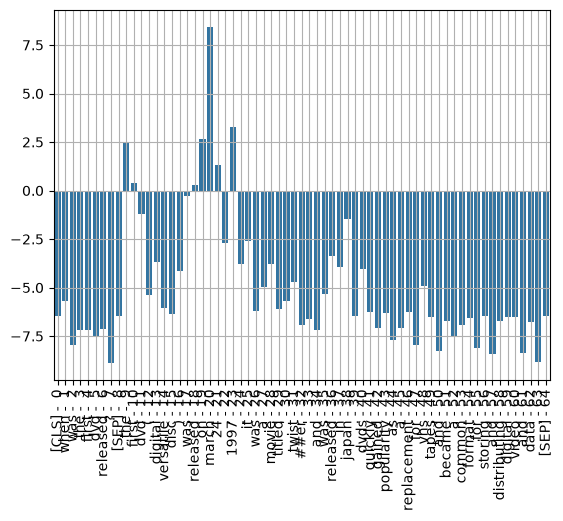

In [24]:

ax = sns.barplot(x=token_labels, y=s_scores)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center") 
ax.grid(True) 

C:\Users\joshu\AppData\Local\Temp\ipykernel_3700\2800425266.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")


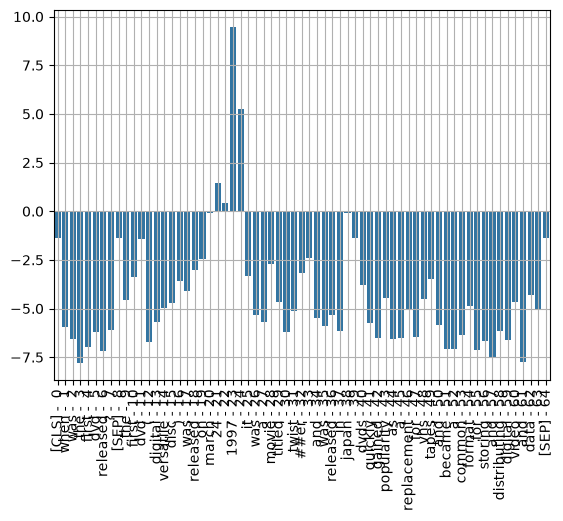

In [25]:
ax = sns.barplot(x=token_labels, y=e_scores)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center") 
ax.grid(True) 

### Question Answering (Mini Project)

In [26]:
sunset_motors_context = "Sunset Motors is a renowned automobile dealership that has been a cornerstone of the automotive industry since its establishment in 1978. Located in the picturesque town of Crestwood, nestled in the heart of California's scenic Central Valley, Sunset Motors has built a reputation for excellence, reliability, and customer satisfaction over the past four decades. Founded by visionary entrepreneur Robert Anderson, Sunset Motors began as a humble, family-owned business with a small lot of used cars. However, under Anderson's leadership and commitment to quality, it quickly evolved into a thriving dealership offering a wide range of vehicles from various manufacturers. Today, the dealership spans over 10 acres, showcasing a vast inventory of new and pre-owned cars, trucks, SUVs, and luxury vehicles. One of Sunset Motors' standout features is its dedication to sustainability. In 2010, the dealership made a landmark decision to incorporate environmentally friendly practices, including solar panels to power the facility, energy-efficient lighting, and a comprehensive recycling program. This commitment to eco-consciousness has earned Sunset Motors recognition as an industry leader in sustainable automotive retail. Sunset Motors proudly offers a diverse range of vehicles, including popular brands like Ford, Toyota, Honda, Chevrolet, and BMW, catering to a wide spectrum of tastes and preferences. In addition to its outstanding vehicle selection, Sunset Motors offers flexible financing options, allowing customers to secure affordable loans and leases with competitive interest rates."
print(sunset_motors_context)

Sunset Motors is a renowned automobile dealership that has been a cornerstone of the automotive industry since its establishment in 1978. Located in the picturesque town of Crestwood, nestled in the heart of California's scenic Central Valley, Sunset Motors has built a reputation for excellence, reliability, and customer satisfaction over the past four decades. Founded by visionary entrepreneur Robert Anderson, Sunset Motors began as a humble, family-owned business with a small lot of used cars. However, under Anderson's leadership and commitment to quality, it quickly evolved into a thriving dealership offering a wide range of vehicles from various manufacturers. Today, the dealership spans over 10 acres, showcasing a vast inventory of new and pre-owned cars, trucks, SUVs, and luxury vehicles. One of Sunset Motors' standout features is its dedication to sustainability. In 2010, the dealership made a landmark decision to incorporate environmentally friendly practices, including solar p

In [27]:
def faq_bot(question):

    context = sunset_motors_context
    input_ids = tokenizer.encode(question, context)
    tokens = tokenizer.convert_ids_to_tokens(input_ids)
    sep_idx = input_ids.index(tokenizer.sep_token_id)
    num_seg_a = sep_idx+1
    num_seg_b = len(input_ids) - num_seg_a
    segment_ids = [0]*num_seg_a + [1]*num_seg_b
    output = model(torch.tensor([input_ids]), token_type_ids = torch.tensor([segment_ids]))
    answer_start = torch.argmax(output.start_logits)
    answer_end = torch.argmax(output.end_logits)
    if answer_end >= answer_start:
        answer = ' '.join(tokens[answer_start:answer_end+1])
    else:
        print("I don't know how to answer this question, can you ask another one?")
    corrected_answer = ''
    for word in answer.split():
        if word[0:2] == '##':
            corrected_answer += word[2:]
        else:
            corrected_answer += ' ' + word
    return corrected_answer

#### FAQ Bot Code Explanation

The `faq_bot()` function creates a simple FAQ chatbot using a pretrained BERT Question Answering model.

* The function takes a **question** from the user.
* It uses `sunset_motors_context` as the **source of information**.
* The tokenizer converts the question and context into tokens and token IDs.
* The code creates **segment IDs** to distinguish the question from the context.
* The question, context, and segment information are passed to the **BERT QA model**.
* BERT calculates `start_logits` and `end_logits` to predict where the answer begins and ends.
* `torch.argmax()` selects the positions with the highest scores.
* The tokens between these positions are extracted as the answer.
* The code then corrects BERT's **subword tokens**, such as `##ing`, to make the answer readable.
* Finally, the cleaned answer is returned.

**In simple terms:** The chatbot receives a question, searches for the answer inside the given context using BERT, extracts the relevant text, cleans it, and returns it as the final answer.


In [28]:
faq_bot("Where is the dealership located?")

' crestwood'

In [29]:
faq_bot("what make of cars are available?")

' ford , toyota , honda , chevrolet , and bmw'

In [30]:
faq_bot("how large is the dealership?") 

' 10 acres'

#### RoBERTa and DistilBERT

In [31]:
from transformers import RobertaTokenizer, RobertaModel
model_name = "roberta-base"
tokenizer = RobertaTokenizer.from_pretrained(model_name)
model = RobertaModel.from_pretrained(model_name)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [32]:
from transformers import  DistilBertTokenizer, DistilBertModel 
model_name = "distilbert-base-uncased"
tokenizer =  DistilBertTokenizer.from_pretrained(model_name)
model = DistilBertModel.from_pretrained(model_name)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


#### BERT Question Answering Process

1. **Load the pretrained BERT QA model**
   A pretrained BERT model fine-tuned on the SQuAD dataset is loaded using `BertForQuestionAnswering`. This model is already trained to find answers from a given context.

2. **Load the tokenizer**
   `BertTokenizer` converts the question and context into tokens and then into numerical token IDs that BERT can understand.

3. **Provide the question and context**
   The question and the answer document are given to the tokenizer using `encode_plus()`. The question asks what we want to know, while the context contains the information needed to answer it.

4. **Create BERT inputs**
   The tokenizer produces `input_ids`, `token_type_ids`, and `attention_mask`. `input_ids` represent the tokens, while `token_type_ids` tell BERT which tokens belong to the question and which belong to the context.

5. **Add special tokens**
   BERT uses `[CLS]` at the beginning and `[SEP]` to separate the question from the context. These tokens help BERT understand the structure of the input.

6. **Pass the input to BERT**
   The token IDs and segment IDs are passed to the pretrained BERT question-answering model. BERT processes the question and context using its Transformer Encoder and understands the relationship between them.

7. **Predict the answer start position**
   BERT produces `start_logits`, which give a score for every token indicating how likely that token is to be the beginning of the answer. `torch.argmax()` selects the token with the highest score.

8. **Predict the answer end position**
   BERT produces `end_logits`, which give a score for every token indicating how likely that token is to be the end of the answer. `torch.argmax()` selects the token with the highest score.

9. **Extract the answer**
   The tokens between the predicted start and end positions are selected from the context.

10. **Convert tokens into readable text**
    The selected tokens are joined together to form the final answer. For example, the tokens `march`, `24`, `,`, `1997` produce the answer **March 24, 1997**.

**Important:** BERT QA does not generate a new answer like GPT. It finds the position of the answer within the provided context and extracts those tokens.

#### RoBERTa Process

1. **Load the pretrained RoBERTa model**
   `RobertaModel.from_pretrained("roberta-base")` loads a pretrained RoBERTa model that has already learned language patterns from a large amount of text.

2. **Load the tokenizer**
   `RobertaTokenizer` converts input text into tokens and numerical token IDs that RoBERTa can process.

3. **Provide the text**
   The input text is passed to the tokenizer, which prepares it in the format required by RoBERTa.

4. **Process the input**
   The token IDs are passed to RoBERTa's Transformer Encoder. RoBERTa uses bidirectional attention to understand the meaning of each word based on the surrounding words.

5. **Generate contextual representations**
   RoBERTa produces numerical representations (embeddings) for the input tokens. These representations contain contextual information about the text.

**Important:** `roberta-base` is a base language model. It is not automatically a question-answering model, so a task-specific RoBERTa model or additional fine-tuning is required for tasks such as question answering.

#### DistilBERT Process

1. **Load the pretrained DistilBERT model**
   `DistilBertModel.from_pretrained("distilbert-base-uncased")` loads a smaller pretrained version of BERT.

2. **Load the tokenizer**
   `DistilBertTokenizer` converts the input text into tokens and numerical token IDs.

3. **Provide the text**
   The input text is given to the tokenizer, which prepares the data for DistilBERT.

4. **Process the input**
   The token IDs are passed through DistilBERT's Transformer layers. DistilBERT uses fewer layers than BERT, making it faster and lighter.

5. **Generate contextual representations**
   DistilBERT produces contextual representations of the input text that can be used for different NLP tasks.

**Important:** DistilBERT is designed to provide much of BERT's language understanding while using fewer resources and providing faster inference. Like the base BERT/RoBERTa models, it needs task-specific fine-tuning for tasks such as question answering or sentiment classification.


---

#### 13) XLNet

##### Definition

**XLNet** is a Transformer-based language model developed as an improvement over models such as BERT. It uses a **permutation language modeling** approach, which allows the model to learn relationships between words from different ordering patterns while still using information from both directions.

XLNet is based on the **Transformer-XL architecture**, which helps it handle longer sequences and capture relationships between distant words.

##### Key Features

* **Permutation Language Modeling:** XLNet predicts tokens using different possible orders instead of simply masking tokens like BERT.
* **Bidirectional Context:** It can learn information from both the left and right sides of a word.
* **Transformer-XL:** Helps XLNet handle longer text and dependencies between distant words.
* **No `[MASK]` token during pretraining:** Unlike BERT, XLNet does not depend on masking tokens in the same way.
* **Pretrained Model:** It can be fine-tuned for different NLP tasks.

##### Usage of XLNet

XLNet can be used for several NLP tasks, such as:

* **Text Classification** – classifying text into categories.
* **Question Answering** – finding answers from a given context.
* **Sentiment Analysis** – identifying positive, negative, or neutral sentiment.
* **Text Classification** – categorizing documents, emails, or messages.
* **Natural Language Understanding** – understanding the meaning and relationship between words.

### XLNet Example

```python
from transformers import XLNetTokenizer, XLNetForSequenceClassification

tokenizer = XLNetTokenizer.from_pretrained("xlnet-base-cased")
model = XLNetForSequenceClassification.from_pretrained(
    "xlnet-base-cased",
    num_labels=2
)
```

Here, the tokenizer converts text into tokens, while `XLNetForSequenceClassification` adds a classification layer on top of XLNet so that it can classify text into different categories.

#### Text Classification

##### Definition

**Text classification** is an NLP task where a model assigns predefined categories or labels to a piece of text.

For example:

```text
"I really enjoyed this movie."
→ Positive

"I didn't like this movie."
→ Negative
```

The model learns patterns from training data and then predicts the appropriate class for new text.

##### Common Applications

Text classification is used for:

* **Sentiment Analysis:** Positive, Negative, Neutral
* **Spam Detection:** Spam, Not Spam
* **News Classification:** Sports, Politics, Technology, Business
* **Email Classification:** Important, Promotion, Spam
* **Intent Classification:** Booking, Cancellation, Payment, Complaint
* **Topic Classification:** Identifying the topic of a document

##### Text Classification Process

1. **Input Text**
   The user provides a piece of text.

2. **Tokenization**
   The tokenizer converts the text into tokens and numerical token IDs.

3. **Model Processing**
   A pretrained Transformer model such as BERT, RoBERTa, DistilBERT, or XLNet processes the tokenized text.

4. **Classification Layer**
   A classification layer receives the model's representation of the text and produces scores for each possible class.

5. **Class Prediction**
   The class with the highest score is selected as the predicted category.

##### Example

Suppose we have three classes:

```text
0 → Negative
1 → Neutral
2 → Positive
```

Input:

```text
"The product quality is excellent."
```

The model may produce scores such as:

```text
Negative → 0.02
Neutral  → 0.08
Positive → 0.90
```

Since **Positive** has the highest score, the final prediction is:

```text
Positive
```

##### Important Difference

**Question Answering** finds the answer within a given context, while **Text Classification** assigns the entire input text to one of the predefined categories.

For example:

**Question Answering:**

> "Where is the dealership located?"
> → "Crestwood"

**Text Classification:**

> "The dealership has excellent customer service."
> → "Positive"


---

### Text Classification With XLNET

In [1]:
import pandas as pd
import numpy as np
from cleantext import clean
import re
from transformers import XLNetTokenizer, XLNetForSequenceClassification, TrainingArguments, Trainer, pipeline
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import datasets 
import evaluate
import random

#### Preprocess Our Data

In [2]:
data_train = pd.read_csv('./emotions_data/emotion-labels-train.csv') 
data_test = pd.read_csv('./emotions_data/emotion-labels-test.csv')
data_val = pd.read_csv('./emotions_data/emotion-labels-val.csv')
# data should be saved in a folder called 'emotions' which is saved in the same place as your notebook

In [3]:
data_train.head()

,text,label
0,Just got back from seeing @GaryDelaney in Burs...,joy
1,Oh dear an evening of absolute hilarity I don'...,joy
2,Been waiting all week for this game ❤️❤️❤️ #ch...,joy
3,"@gardiner_love : Thank you so much, Gloria! Yo...",joy
4,I feel so blessed to work with the family that...,joy


In [4]:
data = pd.concat([data_train, data_test, data_val], ignore_index=True)

In [5]:
data['text_clean'] = data['text'].apply(lambda x: clean(x, no_emoji=True))

In [6]:
data['text_clean'] = data['text_clean'].apply(lambda x: re.sub('@[^\s]+', '', x))

In [7]:
data.head(20)

,text,label,text_clean
0,Just got back from seeing @GaryDelaney in Burs...,joy,just got back from seeing in burslem. amazing...
1,Oh dear an evening of absolute hilarity I don'...,joy,oh dear an evening of absolute hilarity i don'...
2,Been waiting all week for this game ❤️❤️❤️ #ch...,joy,been waiting all week for this game #cheer #fr...
3,"@gardiner_love : Thank you so much, Gloria! Yo...",joy,": thank you so much, gloria! you're so sweet,..."
4,I feel so blessed to work with the family that...,joy,i feel so blessed to work with the family that...
5,"Today I reached 1000 subscribers on YT!! , #go...",joy,"today i reached 1000 subscribers on yt!! , #go..."
6,"@Singaholic121 Good morning, love! Happy first...",joy,"good morning, love! happy first day of fall. ..."
7,#BridgetJonesBaby is the best thing I've seen ...,joy,#bridgetjonesbaby is the best thing i've seen ...
8,Just got back from seeing @GaryDelaney in Burs...,joy,just got back from seeing in burslem. amazing...
9,@IndyMN I thought the holidays could not get a...,joy,i thought the holidays could not get any more...


<Axes: xlabel='label'>

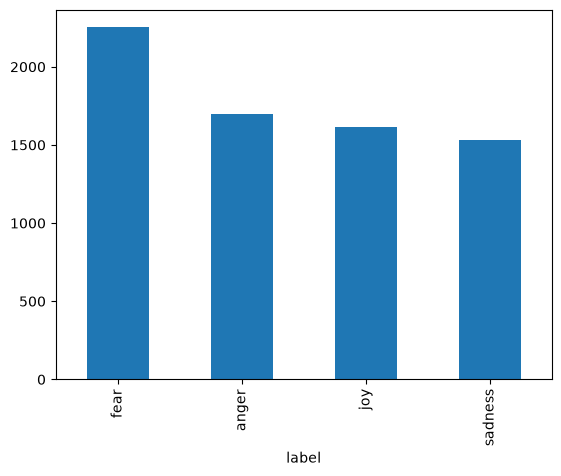

In [8]:
data['label'].value_counts().plot(kind="bar")

In [9]:
g = data.groupby('label')
data = pd.DataFrame(g.apply(lambda x: x.sample(g.size().min()).reset_index(drop=True)))

<Axes: xlabel='label'>

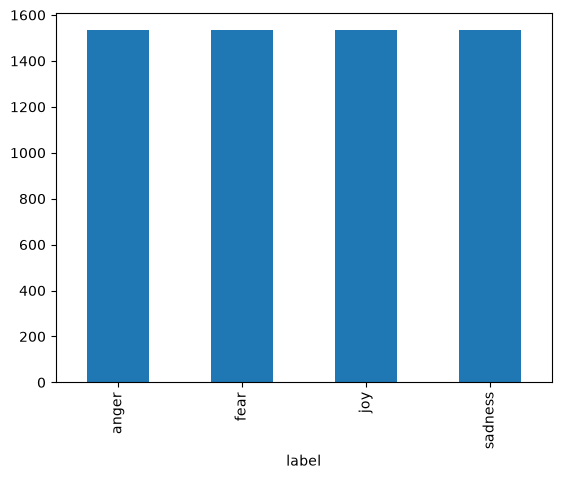

In [10]:
data['label'].value_counts().plot(kind="bar")

In [11]:
data['label_int'] = LabelEncoder().fit_transform(data['label'])

In [12]:
NUM_LABELS = 4

In [13]:
train_split, test_split = train_test_split(data, train_size = 0.8)
train_split, val_split = train_test_split(train_split, train_size = 0.9)

In [14]:
print(len(train_split))
print(len(test_split))
print(len(val_split))

4414
1227
491


In [15]:
train_df = pd.DataFrame({
    "label": train_split.label_int.values,
    "text": train_split.text_clean.values
})

test_df = pd.DataFrame({
    "label": test_split.label_int.values,
    "text": test_split.text_clean.values
})

In [16]:
train_df = datasets.Dataset.from_dict(train_df)
test_df = datasets.Dataset.from_dict(test_df)

In [17]:
dataset_dict = datasets.DatasetDict({"train":train_df, "test":test_df})

In [18]:
dataset_dict

DatasetDict({
    train: Dataset({
        features: ['label', 'text'],
        num_rows: 4414
    })
    test: Dataset({
        features: ['label', 'text'],
        num_rows: 1227
    })
})

#### Create Embeddings

In [19]:
tokenizer = XLNetTokenizer.from_pretrained("xlnet-base-cased")

In [20]:
def tokenize_function(examples):
    return tokenizer(examples["text"], padding = "max_length", max_length = 128, truncation=True)

In [21]:
tokenized_datasets = dataset_dict.map(tokenize_function, batched=True)

Map:   0%|          | 0/4414 [00:00<?, ? examples/s]

Map:   0%|          | 0/1227 [00:00<?, ? examples/s]

In [22]:
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['label', 'text', 'input_ids', 'attention_mask'],
        num_rows: 4414
    })
    test: Dataset({
        features: ['label', 'text', 'input_ids', 'attention_mask'],
        num_rows: 1227
    })
})

In [23]:
print(tokenized_datasets['train']['text'][0])

like hello? i am your first born you must always laugh at my jokes.


In [24]:
print(tokenized_datasets['train']['input_ids'][0])

[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 115, 24717, 82, 17, 150, 569, 73, 89, 1094, 44, 272, 426, 5361, 38, 94, 14331, 9, 4, 3]


In [25]:
tokenizer.decode(5)

'<pad>'

In [27]:
print(tokenized_datasets['train']['input_ids'][0])

[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 115, 24717, 82, 17, 150, 569, 73, 89, 1094, 44, 272, 426, 5361, 38, 94, 14331, 9, 4, 3]


In [28]:
print(tokenized_datasets['train']['attention_mask'][0])

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [29]:
small_train_dataset = tokenized_datasets["train"].shuffle(seed=42).select(range(100))
small_eval_dataset = tokenized_datasets["test"].shuffle(seed=42).select(range(100))

#### Fine Tune Our Model

In [30]:
model = XLNetForSequenceClassification.from_pretrained('xlnet-base-cased', 
                                                       num_labels=NUM_LABELS, 
                                                       id2label={0: 'anger', 1: 'fear', 2: 'joy', 3: 'sadness'})

Loading weights:   0%|          | 0/206 [00:00<?, ?it/s]

[transformers] XLNetForSequenceClassification LOAD REPORT from: xlnet-base-cased
Key                             | Status     | 
--------------------------------+------------+-
lm_loss.weight                  | UNEXPECTED | 
lm_loss.bias                    | UNEXPECTED | 
logits_proj.bias                | MISSING    | 
sequence_summary.summary.bias   | MISSING    | 
sequence_summary.summary.weight | MISSING    | 
logits_proj.weight              | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [31]:
metric = evaluate.load("accuracy")

In [32]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

In [33]:
training_args = TrainingArguments(output_dir="test_trainer", eval_strategy="epoch", num_train_epochs=3)

In [34]:
trainer = Trainer(
    model=model, 
    args=training_args,
    train_dataset=small_train_dataset,
    eval_dataset=small_eval_dataset,
    compute_metrics=compute_metrics)

In [35]:
trainer.train()

C:\Users\joshu\anaconda3\envs\llms_course_env\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,1.406702,0.250000
2,No log,1.461956,0.260000
3,No log,1.425983,0.300000


C:\Users\joshu\anaconda3\envs\llms_course_env\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\joshu\anaconda3\envs\llms_course_env\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\joshu\anaconda3\envs\llms_course_env\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=39, training_loss=1.3462252494616387, metrics={'train_runtime': 327.7251, 'train_samples_per_second': 0.915, 'train_steps_per_second': 0.119, 'total_flos': 21366375321600.0, 'train_loss': 1.3462252494616387, 'epoch': 3.0})

#### Evaluate Model

In [36]:

trainer.evaluate()

C:\Users\joshu\anaconda3\envs\llms_course_env\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy
No log,1.425983,3,0.300000


{'eval_loss': 1.4259833097457886, 'eval_accuracy': 0.3}

In [37]:
model.save_pretrained("fine_tuned_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [41]:
fine_tuned_model = XLNetForSequenceClassification.from_pretrained("fine_tuned_model")

Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

In [42]:
clf = pipeline("text-classification", fine_tuned_model, tokenizer=tokenizer)

In [43]:
rand_int = random.randint(0, len(val_split))
print(val_split['text_clean'][rand_int])
answer = clf(val_split['text_clean'][rand_int], top_k=None)
print(answer)

watch this amazing live.ly broadcast by  #musically
[{'label': 'joy', 'score': 0.3724210858345032}, {'label': 'fear', 'score': 0.24463213980197906}, {'label': 'anger', 'score': 0.20282484591007233}, {'label': 'sadness', 'score': 0.18012185394763947}]
